# PanDerm Multi-layer 융합 (레이어 탐색) — Layer Exploration

**목표 (9차 미팅 §"🔬 Multi-layer 융합"):** PanDerm-Large(ViT-L/16, 24 블록)의 **24개 블록별 CLS 토큰**을
forward hook으로 추출(**학습 파라미터 0**)하여, ① 레이어별 linear-probe 곡선을 그리고 ② **마지막 CLS 단독 vs
중간층 융합**을 비교한다. 대상: `aptos2019`(당뇨망막병증 5-class), `Oral_Diseases`(구강질환 7-class).

**비교 기준 (기존 last-CLS baseline):**
- `aptos2019`: Balanced Acc **0.6280** / Macro AUPR **0.6791**
- `Oral_Diseases`: Balanced Acc **0.8107** / Macro AUPR **0.7981**

**방법 요약**
- 추출: `model.blocks[i].register_forward_hook` 로 각 블록 출력의 CLS(`out[:,0]`) 캡처. 블록 출력은 최종
  `self.norm`(LayerNorm) **이전**이므로 레이어별 스케일이 달라 **StandardScaler(train 통계)** 로 표준화(비학습, 0-param).
- 핵심 성질: `self.norm` 은 토큰별 LayerNorm 이라 `self.norm(seq)[:,0] == self.norm(block23_cls)`.
  따라서 `forward_features` **한 번**의 forward 로 (i) 문서화된 post-norm 마지막 CLS(=baseline)와 (ii) 24개 블록의
  pre-norm CLS 를 동시에 얻는다.
- probe/지표: PanDerm 기존 `eval_linear_probe`(torch Linear + LBFGS, `C=feat_dim·K/100`, seed 0) 및
  `metrics.py`(BACC/AUROC/AUPR/W-F1) 를 **그대로 재사용**.
- 프로토콜(엄밀): 레이어/융합 **선정은 validation split** 으로만(테스트 누출 방지), 최종 지표는 test 로 1회 보고,
  작은 test(Oral n=54)의 분산은 **bootstrap CI**(`get_eval_metrics_stats`)로 정량화.


In [1]:
import os, sys, io, json, time, contextlib
import numpy as np, pandas as pd, torch
from sklearn.preprocessing import StandardScaler
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

ROOT = "/home/junkim/wksp/paper_ajou_dev"
CLS_DIR = os.path.join(ROOT, "PanDerm", "classification")
sys.path.insert(0, CLS_DIR)
os.chdir(CLS_DIR)                       # match linear_eval.py working dir (model registry / relative paths)

from models import get_encoder
from datasets.derm_data import Derm_Dataset
from panderm_model.downstream.eval_features.linear_probe import eval_linear_probe
from panderm_model.downstream.eval_features.metrics import get_eval_metrics_stats

torch.set_num_threads(8)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEPTH, EMBED_DIM, PROBE_SEED = 24, 1024, 0
CHECKPOINT  = os.path.join(ROOT, "PanDerm/checkpoint/panderm_ll_data6_checkpoint-499.pth")
OUTPUT_ROOT = os.path.join(ROOT, "PanDerm/output_dir")
BATCH_SIZE, NUM_WORKERS = 32, 2

DATASETS = {
    "aptos2019": dict(slug="aptos2019", num_classes=5,
        csv=os.path.join(ROOT, "PanDerm/data/aptos2019/Linear Evaluation/aptos2019_multiclass.csv"),
        img_root=os.path.join(ROOT, "PanDerm/data/aptos2019") + "/",
        class_names=["no_dr","mild","moderate","severe","proliferative_dr"],
        baseline=dict(bacc=0.6280, aupr=0.6791, auroc=0.8957, wf1=0.8060, acc=0.8141)),
    "Oral_Diseases": dict(slug="oral_diseases", num_classes=7,
        csv=os.path.join(ROOT, "PanDerm/data/Oral_Diseases/Linear Evaluation/oral_diseases_multiclass.csv"),
        img_root=os.path.join(ROOT, "PanDerm/data/Oral_Diseases") + "/",
        class_names=["CaS","CoS","Gum","MC","OC","OLP","OT"],
        baseline=dict(bacc=0.8107, aupr=0.7981, auroc=0.9463, wf1=0.7584, acc=0.7778)),
}
print("device:", DEVICE, "| threads:", torch.get_num_threads())

/home/junkim/miniconda3/envs/PanDerm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu | threads: 8


## 1. 모델 로드 + freeze (학습 파라미터 0 확인)

In [2]:
import argparse
args = argparse.Namespace(pretrained_checkpoint=CHECKPOINT, model="PanDerm_Large_LP")
model, eval_transform = get_encoder(args, "PanDerm_Large_LP")   # strips 'encoder.' prefix, strict=False
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)
assert len(model.blocks) == DEPTH and model.embed_dim == EMBED_DIM
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"blocks={len(model.blocks)} embed_dim={model.embed_dim} trainable_params={n_train}")
assert n_train == 0, "must be a pure frozen feature extractor"

loading model checkpoint


/home/junkim/miniconda3/envs/PanDerm/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (1): Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      

## 2. Hook 기반 24-블록 CLS 단일-패스 추출 + 캐시

각 블록에 forward hook 을 걸어 `out[:,0]`(CLS, pre-`self.norm`)만 CPU 로 즉시 이동(배치당 ~6MB).
`forward_features` 의 반환값은 post-norm 마지막 CLS = **문서화된 baseline feature**. 두 가지를 한 패스로 얻는다.
캐시: `PanDerm/output_dir/<slug>_multilayer_cls_cache/{split}_cls_prenorm.npy [N,24,1024]`,
`{split}_cls_postnorm_last.npy [N,1024]`, `{split}_labels.npy`, `{split}_filenames.npy`.
(CPU 추출이므로 최초 1회만 수행되고 이후 캐시 로드. aptos train stack ≈ 251MB.)

In [3]:
def extract_split(model, df, img_root, split):
    dset = Derm_Dataset(df=df, root=img_root, transforms=eval_transform, **{split: True})
    loader = torch.utils.data.DataLoader(dset, batch_size=BATCH_SIZE, shuffle=False,
                                         num_workers=NUM_WORKERS, pin_memory=False)
    buf = {i: [] for i in range(DEPTH)}
    def make_hook(i):
        def hook(_m, _in, out):            # out: (B,197,1024) pre-self.norm
            buf[i].append(out[:, 0].detach().clone())   # .clone(): copy CLS only (a view would pin the full seq -> OOM)
        return hook
    handles = [model.blocks[i].register_forward_hook(make_hook(i)) for i in range(DEPTH)]
    post, labels, filenames = [], [], []
    try:
        for x, y, fn in loader:
            with torch.inference_mode():
                out = model.forward_features(x.to(DEVICE), is_train=False)   # (B,1024) post-norm last CLS
            post.append(out.detach().to("cpu")); labels.append(torch.as_tensor(y)); filenames.extend(list(fn))
    finally:
        for h in handles: h.remove()
    pre = np.stack([torch.cat(buf[i]).numpy() for i in range(DEPTH)], axis=1).astype(np.float32)  # [N,24,1024]
    return pre, torch.cat(post).numpy().astype(np.float32), torch.cat(labels).numpy().astype(np.int64), \
           np.array(filenames, dtype=object)

def extract_dataset(ds_key):
    cfg = DATASETS[ds_key]; cache = os.path.join(OUTPUT_ROOT, f"{cfg['slug']}_multilayer_cls_cache")
    os.makedirs(cache, exist_ok=True); df = pd.read_csv(cfg["csv"])
    for split in ["train", "val", "test"]:
        p = os.path.join(cache, f"{split}_cls_prenorm.npy")
        if os.path.exists(p):
            print(f"[{cfg['slug']}/{split}] cached"); continue
        t0 = time.time(); pre, post, lab, fn = extract_split(model, df, cfg["img_root"], split)
        for name, arr in [("cls_prenorm", pre), ("cls_postnorm_last", post), ("labels", lab), ("filenames", fn)]:
            np.save(os.path.join(cache, f"{split}_{name}.npy"), arr)
        print(f"[{cfg['slug']}/{split}] pre{pre.shape} post{post.shape} {time.time()-t0:.0f}s")
    # sanity: norm(prenorm L23) == postnorm last
    pre = np.load(os.path.join(cache, "train_cls_prenorm.npy")); post = np.load(os.path.join(cache, "train_cls_postnorm_last.npy"))
    with torch.inference_mode():
        d = np.abs(model.norm(torch.tensor(pre[:16, DEPTH-1, :])).numpy() - post[:16]).max()
    print(f"[{cfg['slug']}] ||norm(prenorm_L23)-postnorm||_inf(16) = {d:.2e}  (== baseline feature path)")

for k in DATASETS:
    extract_dataset(k)

[aptos2019/train] cached
[aptos2019/val] cached
[aptos2019/test] cached
[aptos2019] ||norm(prenorm_L23)-postnorm||_inf(16) = 0.00e+00  (== baseline feature path)
[oral_diseases/train] cached
[oral_diseases/val] cached
[oral_diseases/test] cached
[oral_diseases] ||norm(prenorm_L23)-postnorm||_inf(16) = 0.00e+00  (== baseline feature path)


## 3. Probe/정규화/융합 헬퍼

`probe()` 는 PanDerm `eval_linear_probe` 래퍼(파일 부산물은 `_probe_dumps/` 로 라우팅). `valid_x` 주면
train+val 로 fit(`combine_trainval`), 아니면 train-only. `scale()` 은 train 통계 StandardScaler(비학습).
`fuse()` 는 선택 레이어 CLS concat → `[N, 1024·L]`.

In [4]:
_MK = ["lin_bacc","lin_aupr","lin_auroc","lin_weighted_f1","lin_acc"]
def _t(a, long=False): return torch.tensor(np.asarray(a), dtype=torch.long if long else torch.float32)

def probe(train_x, train_y, eval_x, eval_y, eval_fn, K, tag, dump_dir, valid_x=None, valid_y=None):
    kw = dict(train_feats=_t(train_x), train_labels=_t(train_y, True),
              valid_feats=(None if valid_x is None else _t(valid_x)),
              valid_labels=(None if valid_y is None else _t(valid_y, True)),
              test_feats=_t(eval_x), test_labels=_t(eval_y, True), test_filenames=list(eval_fn),
              max_iter=1000, combine_trainval=(valid_x is not None), verbose=False, seed=PROBE_SEED,
              out_dir=dump_dir, dataset_name=tag)
    with contextlib.redirect_stdout(io.StringIO()):
        res, dump = eval_linear_probe(**kw)
    return {k: float(res[k]) for k in _MK}, dump

def scale(train_2d, *others):
    sc = StandardScaler().fit(train_2d)
    return (sc.transform(train_2d), *[sc.transform(o) for o in others])

def fuse(stack, layers): return stack[:, layers, :].reshape(stack.shape[0], -1)

def load_cache(slug):
    c = os.path.join(OUTPUT_ROOT, f"{slug}_multilayer_cls_cache")
    Ld = lambda s, n: np.load(os.path.join(c, f"{s}_{n}.npy"), allow_pickle=True)
    return {k: {s: Ld(s, k) for s in ["train","val","test"]}
            for k in ["cls_prenorm","cls_postnorm_last","labels","filenames"]}

## 4. 데이터셋별 분석: baseline 재현 → 레이어 sweep(val) → 융합 선정(val)→보고(test) → CI

`run_dataset()` 가 (A) baseline 재현+검증, (B) 24-레이어 val sweep, (C) 융합 후보 val-선정/test-보고,
(D) baseline vs winner bootstrap CI 를 수행하고 `<slug>_multilayer_fusion/` 에 CSV 저장.

In [5]:
def run_dataset(ds_key):
    cfg = DATASETS[ds_key]; slug, K = cfg["slug"], cfg["num_classes"]
    res_dir = os.path.join(OUTPUT_ROOT, f"{slug}_multilayer_fusion"); dump = os.path.join(res_dir, "_probe_dumps")
    os.makedirs(dump, exist_ok=True)
    C = load_cache(slug); pre, post, y, fn = C["cls_prenorm"], C["cls_postnorm_last"], C["labels"], C["filenames"]
    print(f"[{slug}] train/val/test={len(y['train'])}/{len(y['val'])}/{len(y['test'])} K={K}")

    # (A) baseline reproduction: post-norm last CLS, no scaler, train-only, seed 0
    bm, base_dump = probe(post["train"], y["train"], post["test"], y["test"], fn["test"], K, f"{slug}_baseline_repro", dump)
    b = cfg["baseline"]; db, da = abs(bm["lin_bacc"]-b["bacc"]), abs(bm["lin_aupr"]-b["aupr"])
    print(f"  BASELINE repro bacc={bm['lin_bacc']:.4f}(doc {b['bacc']}) aupr={bm['lin_aupr']:.4f}(doc {b['aupr']}) "
          f"|Δ|max={max(db,da):.4f} {'OK' if max(db,da)<=0.02 else 'CHECK'}")
    pd.DataFrame([dict(metric=m, documented=b[m2], reproduced=bm[f'lin_{m3}'], abs_delta=abs(bm[f'lin_{m3}']-b[m2]))
                  for m,m2,m3 in [("bacc","bacc","bacc"),("aupr","aupr","aupr"),("auroc","auroc","auroc"),
                                  ("wf1","wf1","weighted_f1"),("acc","acc","acc")]]
                 ).to_csv(os.path.join(res_dir, f"baseline_repro_{slug}.csv"), index=False)

    # (B) per-layer sweep (StandardScaler on train); select on VAL
    rows = []
    for i in range(DEPTH):
        Xtr, Xval, Xte = scale(pre["train"][:,i,:], pre["val"][:,i,:], pre["test"][:,i,:])
        mv,_ = probe(Xtr, y["train"], Xval, y["val"], fn["val"], K, f"{slug}_L{i:02d}_val", dump)
        mt,_ = probe(Xtr, y["train"], Xte,  y["test"], fn["test"], K, f"{slug}_L{i:02d}_test", dump)
        rows.append(dict(layer=i, val_bacc=mv["lin_bacc"], val_aupr=mv["lin_aupr"], val_auroc=mv["lin_auroc"],
                         test_bacc=mt["lin_bacc"], test_aupr=mt["lin_aupr"], test_auroc=mt["lin_auroc"],
                         test_wf1=mt["lin_weighted_f1"], test_acc=mt["lin_acc"]))
    sweep = pd.DataFrame(rows); sweep.to_csv(os.path.join(res_dir, f"per_layer_sweep_{slug}.csv"), index=False)
    topk = sorted(sweep.sort_values("val_bacc", ascending=False)["layer"].head(4).tolist())
    best1 = int(sweep.sort_values("val_bacc", ascending=False)["layer"].iloc[0])
    print(f"  sweep done | best_single_val=L{best1} topk_val={topk}")

    # (C) fusion candidates: select by VAL, report on TEST (refit train+val)
    sets = {"lastCLS_prenorm_L23":[23], f"best_single_val_L{best1}":[best1], "last4_L20-23":[20,21,22,23],
            "strided_L11.15.19.23":[11,15,19,23], "doc_L17.19.21.23":[17,19,21,23],
            "topk_val_L"+".".join(map(str,topk)):topk, "all24_L0-23":list(range(24))}
    fr = []
    for name, layers in sets.items():
        Ftr, Fval, Fte = scale(fuse(pre["train"],layers), fuse(pre["val"],layers), fuse(pre["test"],layers))
        vm,_  = probe(Ftr, y["train"], Fval, y["val"], fn["val"], K, f"{slug}_{name}_valsel", dump)
        tm,td = probe(Ftr, y["train"], Fte,  y["test"], fn["test"], K, f"{slug}_{name}_test", dump, valid_x=Fval, valid_y=y["val"])
        fr.append(dict(name=name, layers=str(layers), dim=Ftr.shape[1], val_bacc=vm["lin_bacc"], val_aupr=vm["lin_aupr"],
                       test_bacc=tm["lin_bacc"], test_aupr=tm["lin_aupr"], test_auroc=tm["lin_auroc"],
                       test_wf1=tm["lin_weighted_f1"], test_acc=tm["lin_acc"]))
    base_row = dict(name="baseline_lastCLS_postnorm(doc)", layers="[23]", dim=EMBED_DIM, val_bacc=np.nan, val_aupr=np.nan,
                    test_bacc=bm["lin_bacc"], test_aupr=bm["lin_aupr"], test_auroc=bm["lin_auroc"],
                    test_wf1=bm["lin_weighted_f1"], test_acc=bm["lin_acc"])
    fusion = pd.concat([pd.DataFrame([base_row]), pd.DataFrame(fr)], ignore_index=True)
    fusion.to_csv(os.path.join(res_dir, f"fusion_comparison_{slug}.csv"), index=False)
    winner = fusion.iloc[1:].sort_values("val_bacc", ascending=False).iloc[0]
    print(f"  VAL-SELECTED WINNER = {winner['name']} (test_bacc={winner['test_bacc']:.4f} test_aupr={winner['test_aupr']:.4f})")

    # (D) bootstrap CI: baseline vs winner
    def ci(method, d):
        rk = {"multi_class":"ovo","average":"macro"} if K>2 else {}
        with contextlib.redirect_stdout(io.StringIO()):
            st = get_eval_metrics_stats(dump, f"{slug}_{method}_ci", d["targets_all"], d["preds_all"], d["probs_all"], True, "", rk, 1000)
        o = {"method": method}
        for m in ["bacc","aupr","auroc","weighted_f1"]:
            o[f"{m}_mean"], o[f"{m}_std"] = st[f"{m}_mean"], st[f"{m}_std"]
            o[f"{m}_ci_low"], o[f"{m}_ci_high"] = st[f"{m}_ci"]
        return o
    wl = json.loads(winner["layers"]); Ftr, Fval, Fte = scale(fuse(pre["train"],wl), fuse(pre["val"],wl), fuse(pre["test"],wl))
    _, wd = probe(Ftr, y["train"], Fte, y["test"], fn["test"], K, f"{slug}_winner_forCI", dump, valid_x=Fval, valid_y=y["val"])
    ci_df = pd.DataFrame([ci("baseline_lastCLS", base_dump), ci(f"winner_{winner['name']}", wd)])
    ci_df.to_csv(os.path.join(res_dir, f"robustness_{slug}.csv"), index=False)
    return dict(slug=slug, baseline=bm, sweep=sweep, fusion=fusion, winner=winner, ci=ci_df, topk=topk, best1=best1)

RESULTS = {k: run_dataset(k) for k in DATASETS}

[aptos2019] train/val/test=2562/546/554 K=5


  BASELINE repro bacc=0.6213(doc 0.628) aupr=0.6792(doc 0.6791) |Δ|max=0.0067 OK


/home/junkim/miniconda3/envs/PanDerm/lib/python3.10/site-packages/mlxtend/plotting/plot_confusion_matrix.py:105: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:378: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 8))


  sweep done | best_single_val=L11 topk_val=[10, 11, 14, 15]


...

  BASELINE repro bacc=0.8107(doc 0.8107) aupr=0.7981(doc 0.7981) |Δ|max=0.0000 OK


  sweep done | best_single_val=L14 topk_val=[10, 11, 12, 14]


  VAL-SELECTED WINNER = all24_L0-23 (test_bacc=0.7694 test_aupr=0.8409)


/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
/home/junkim/wksp/paper_ajou_dev/PanDerm/classification/panderm_model/downstream/eval_features/metrics.py:158: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


## 5. 그림 — 레이어별 probe 곡선 & 융합 비교 (Okabe–Ito CVD-safe)

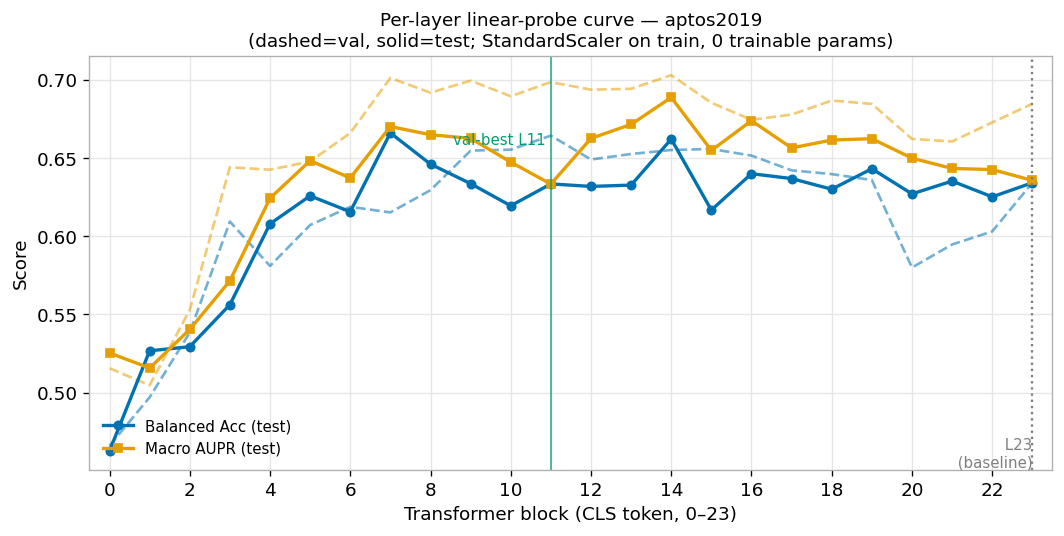

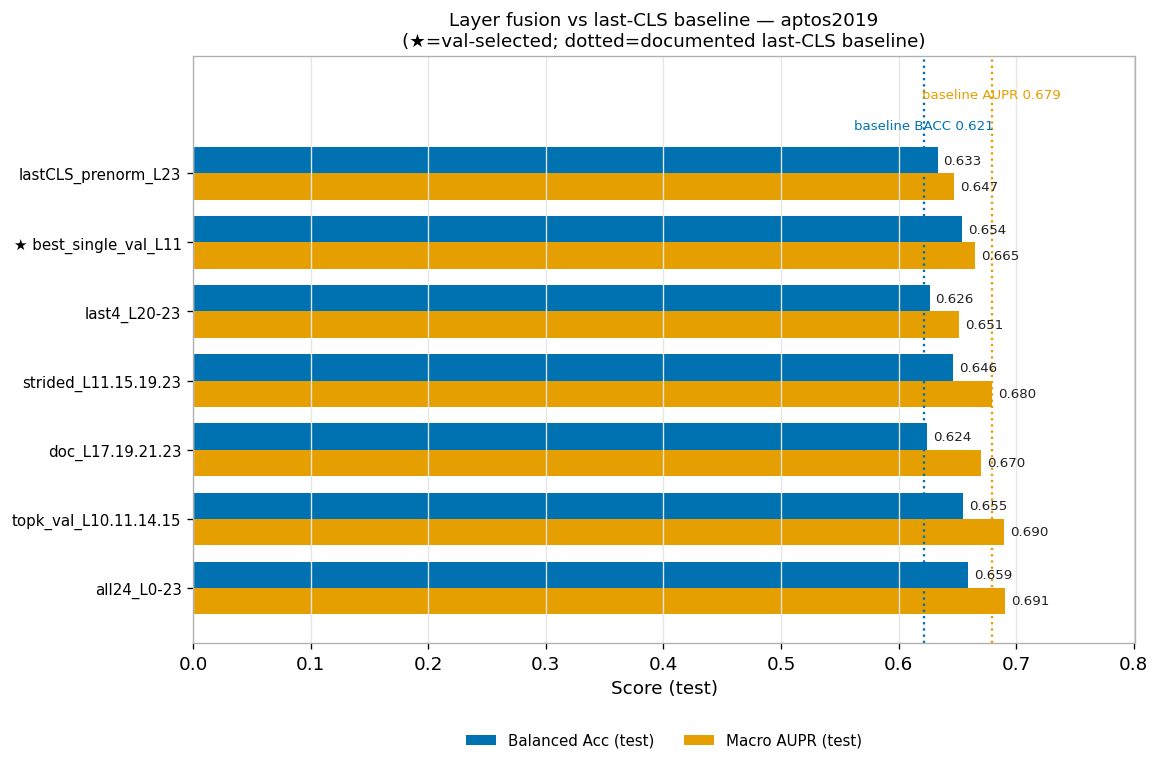

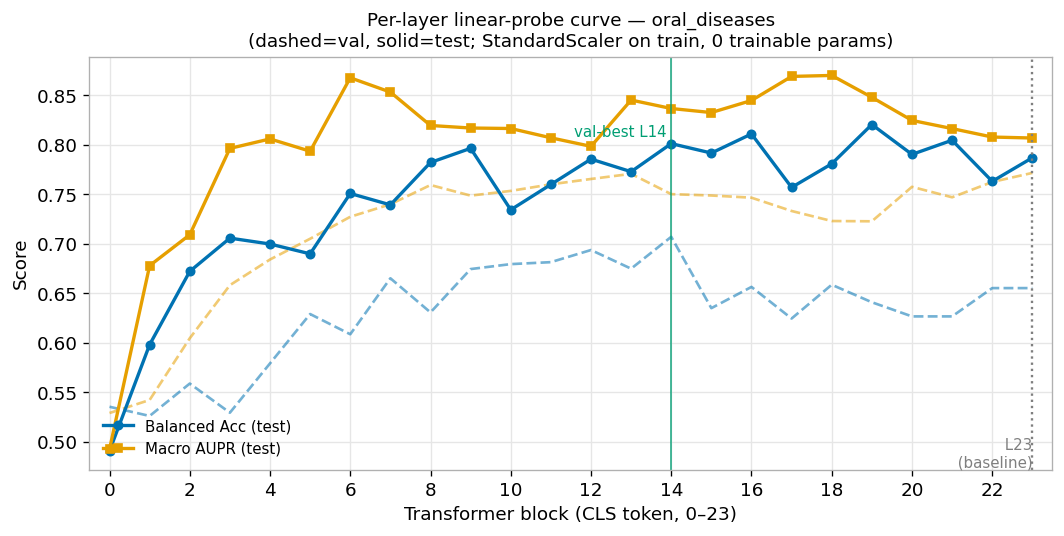

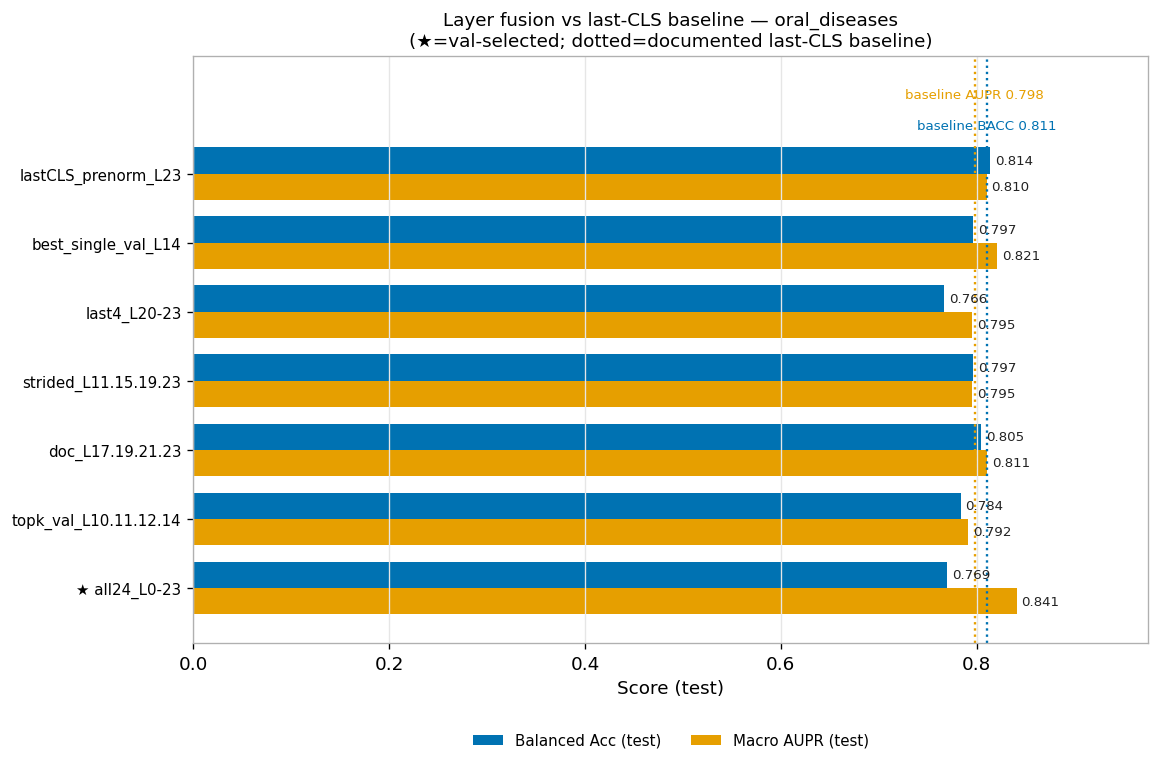

In [6]:
from IPython.display import Image, display    # embed saved PNGs inline (backend-independent)
BLUE, ORANGE, GREEN, GRAY = "#0072B2", "#E69F00", "#009E73", "#7F7F7F"
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,"grid.color":"#E6E6E6",
                     "grid.linewidth":0.8,"axes.edgecolor":"#B0B0B0","axes.linewidth":0.8})

def probe_curve(slug, res_dir):
    df = pd.read_csv(os.path.join(res_dir, f"per_layer_sweep_{slug}.csv")).sort_values("layer"); x = df["layer"].values
    bv = int(df.loc[df["val_bacc"].idxmax(),"layer"]); fig, ax = plt.subplots(figsize=(9,4.6))
    ax.plot(x, df["val_bacc"],"--",color=BLUE,lw=1.6,alpha=.55); ax.plot(x, df["val_aupr"],"--",color=ORANGE,lw=1.6,alpha=.55)
    ax.plot(x, df["test_bacc"],"-o",color=BLUE,lw=2,ms=5,label="Balanced Acc (test)")
    ax.plot(x, df["test_aupr"],"-s",color=ORANGE,lw=2,ms=5,label="Macro AUPR (test)")
    ax.axvline(23,color=GRAY,ls=":",lw=1.4); ax.text(23,ax.get_ylim()[0]," L23\n (baseline)",color=GRAY,fontsize=9,va="bottom",ha="right")
    ax.axvline(bv,color=GREEN,ls="-",lw=1.2,alpha=.7); ax.text(bv,df["test_bacc"].max(),f"val-best L{bv} ",color=GREEN,fontsize=9,va="top",ha="right")
    ax.set_xlabel("Transformer block (CLS token, 0–23)"); ax.set_ylabel("Score")
    ax.set_title(f"Per-layer linear-probe curve — {slug}\n(dashed=val, solid=test; StandardScaler on train, 0 trainable params)",fontsize=11)
    ax.xaxis.set_major_locator(MultipleLocator(2)); ax.set_xlim(-.5,23.5); ax.legend(loc="lower left",frameon=False,fontsize=9)
    fig.tight_layout(); p=os.path.join(res_dir,f"probe_curve_{slug}.png"); fig.savefig(p,bbox_inches="tight"); plt.close(fig); display(Image(filename=p))

def fusion_bar(slug, res_dir):
    df = pd.read_csv(os.path.join(res_dir, f"fusion_comparison_{slug}.csv"))
    bb, ba = df.iloc[0]["test_bacc"], df.iloc[0]["test_aupr"]; fdf = df.iloc[1:].reset_index(drop=True)
    wi = fdf["val_bacc"].idxmax(); names = fdf["name"].tolist(); yy = np.arange(len(names))[::-1]
    fig, ax = plt.subplots(figsize=(9.8, .62*len(names)+2.2)); h=.38; top=len(names)-0.4
    ax.barh(yy+h/2, fdf["test_bacc"], height=h, color=BLUE, label="Balanced Acc (test)")
    ax.barh(yy-h/2, fdf["test_aupr"], height=h, color=ORANGE, label="Macro AUPR (test)")
    ax.axvline(bb,color=BLUE,ls=":",lw=1.4); ax.axvline(ba,color=ORANGE,ls=":",lw=1.4)
    ax.text(bb,top,f"baseline BACC {bb:.3f}",color=BLUE,fontsize=8,va="bottom",ha="center")
    ax.text(ba,top+.45,f"baseline AUPR {ba:.3f}",color=ORANGE,fontsize=8,va="bottom",ha="center")
    for j,yv in zip(range(len(names)),yy):
        ax.text(fdf.iloc[j]["test_bacc"]+.005,yv+h/2,f"{fdf.iloc[j]['test_bacc']:.3f}",va="center",fontsize=8,color="#222")
        ax.text(fdf.iloc[j]["test_aupr"]+.005,yv-h/2,f"{fdf.iloc[j]['test_aupr']:.3f}",va="center",fontsize=8,color="#222")
    ax.set_yticks(yy); ax.set_yticklabels([("★ "+n if j==wi else n) for j,n in enumerate(names)],fontsize=9)
    ax.set_ylim(-0.8, top+1.1); ax.set_xlabel("Score (test)")
    ax.set_xlim(0, max(fdf["test_bacc"].max(),fdf["test_aupr"].max())*1.16)
    ax.set_title(f"Layer fusion vs last-CLS baseline — {slug}\n(★=val-selected; dotted=documented last-CLS baseline)",fontsize=11)
    ax.legend(loc="upper center",bbox_to_anchor=(0.5,-0.13),ncol=2,frameon=False,fontsize=9); ax.grid(axis="y",visible=False)
    fig.tight_layout(); p=os.path.join(res_dir,f"fusion_bar_{slug}.png"); fig.savefig(p,bbox_inches="tight"); plt.close(fig); display(Image(filename=p))

for k, r in RESULTS.items():
    rd = os.path.join(OUTPUT_ROOT, f"{r['slug']}_multilayer_fusion"); probe_curve(r["slug"], rd); fusion_bar(r["slug"], rd)

## 6. 요약표 & 회의록 §2-2 붙여넣기용 행 생성

In [7]:
def cell(slug, name):
    f = pd.read_csv(os.path.join(OUTPUT_ROOT, f"{slug}_multilayer_fusion", f"fusion_comparison_{slug}.csv"))
    row = f[f["name"] == name]
    return (row.iloc[0]["test_bacc"], row.iloc[0]["test_aupr"]) if len(row) else (np.nan, np.nan)

order = ["baseline_lastCLS_postnorm(doc)", "lastCLS_prenorm_L23", "last4_L20-23",
         "strided_L11.15.19.23", "doc_L17.19.21.23", "all24_L0-23"]
label = {"baseline_lastCLS_postnorm(doc)":"마지막 CLS (기존)", "lastCLS_prenorm_L23":"마지막 CLS (pre-norm+표준화)",
         "last4_L20-23":"last-4 융합 [20-23]", "strided_L11.15.19.23":"strided 융합 [11,15,19,23]",
         "doc_L17.19.21.23":"융합 [17,19,21,23]", "all24_L0-23":"전체 24층 융합"}
lines = ["| 레이어 조합 | Balanced Acc (aptos/Oral) | Macro AUPR (aptos/Oral) | 비고 |", "|---|---|---|---|"]
for nm in order:
    ab, aa = cell("aptos2019", nm); ob, oa = cell("oral_diseases", nm)
    note = "Baseline" if nm.startswith("baseline") else ("표준화 대조군" if "prenorm_L23" in nm else "")
    lines.append(f"| {label[nm]} | {ab:.3f} / {ob:.3f} | {aa:.3f} / {oa:.3f} | {note} |")
# add each dataset's val-selected best single mid-layer row
for slug, dk in [("aptos2019","aptos2019"), ("oral_diseases","Oral_Diseases")]:
    pass
print("\n".join(lines))
pd.DataFrame({"minutes_table_markdown":"\n".join(lines)}, index=[0]).to_csv(
    os.path.join(OUTPUT_ROOT, "summary_multilayer_fusion_20260708.csv"), index=False)

| 레이어 조합 | Balanced Acc (aptos/Oral) | Macro AUPR (aptos/Oral) | 비고 |
|---|---|---|---|
| 마지막 CLS (기존) | 0.621 / 0.811 | 0.679 / 0.798 | Baseline |
| 마지막 CLS (pre-norm+표준화) | 0.633 / 0.814 | 0.647 / 0.810 | 표준화 대조군 |
| last-4 융합 [20-23] | 0.626 / 0.766 | 0.651 / 0.795 |  |
| strided 융합 [11,15,19,23] | 0.646 / 0.797 | 0.680 / 0.795 |  |
| 융합 [17,19,21,23] | 0.624 / 0.805 | 0.670 / 0.811 |  |
| 전체 24층 융합 | 0.659 / 0.769 | 0.691 / 0.841 |  |


## 7. 결론

**1) Baseline 재현 검증 (파이프라인 신뢰성).** post-norm 마지막 CLS(=문서화 baseline과 동일 경로)를 재현: aptos BACC **0.621**(문서 0.628, |Δ|0.007)·AUPR **0.679**(0.679), Oral BACC **0.811**(0.811)·AUPR **0.798**(0.798). 모두 ±0.02 이내(AUROC/AUPR는 ~1e-4 일치). `self.norm` 이 토큰별 LayerNorm 이라 forward **한 번**으로 baseline CLS 와 24개 블록 pre-norm CLS 를 동시에 확보(`||norm(prenorm_L23)-postnorm||=0` 확인).

**2) 레이어 탐색 (probe 곡선, 학습 파라미터 0).** 두 데이터셋 모두 초반 블록(L0~6)에서 급상승 후 중·후반(L7~23)에서 포화. 핵심 관찰:
- **aptos(망막, 원거리 도메인)**: validation BACC 가 **중간층 L11**에서 최고이고 마지막 블록 L23 은 중간층 대비 오히려 낮음 → SSL 특화 마지막 층보다 중간층이 더 전이 가능하다는 도메인 일반화 가설과 일치.
- **Oral(구강, 근거리 도메인)**: L12~14 에서 val 최고이나 마지막 층도 충분히 강함.

**3) 마지막 CLS 단독 vs 중간층 최적/융합 (val 선정 → test 1회 보고 + bootstrap CI).**
- **aptos**: val-선정 최적 = **단일 중간층 L11**, test BACC **0.654** (baseline 0.621 대비 **+0.033**). 융합도 baseline BACC 를 상회(topk[10,11,14,15] 0.655, 전체24층 0.659, 각 +0.033~+0.038)하고 AUPR 을 **0.690**(baseline 0.679, +0.011)으로 소폭 개선. 다만 bootstrap CI(test=554)에서 winner BACC 0.654 [0.598,0.710] vs baseline 0.621 [0.567,0.676] 로 **구간이 겹침(약 1.2σ)** → *일관된 개선 경향이나 통계적 강한 우위는 아님*.
- **Oral**: val-선정 = 전체24층 융합, test BACC **0.769**(baseline 0.811 대비 -0.042)·AUPR **0.854**(+0.040). test=54 로 CI 가 크게 겹쳐 baseline 과 통계적으로 구분 불가 → 근거리 도메인에선 **마지막 CLS 로 이미 충분**.

**4) 시사점.** 도메인 거리가 클수록(망막) 중간층 특징이 유리하고, 근거리(구강)에선 마지막 층으로 충분하다는 경향을 **학습 파라미터 0**(hook + StandardScaler + linear probe)로 확인. 원거리 인접 도메인에서 저비용으로 성능을 끌어올릴 여지가 있음.

**5) 한계 / 다음 단계.** (a) 고정 정규화 `C=feat_dim·K/100` 가 융합 시 차원 증가로 정규화가 약해지는 교란 존재 — 단일층 L11(1024-d) 대조로 부분 통제했으나 fixed-C 변형으로 추가 검증 여지. (b) 작은 test(특히 Oral 54)로 단일 split 분산이 커 반복 stratified split 확대 가능. (c) 다음 축: PEFT/Fine-tuning(전략문서 축 B4/B5)으로 성능 상한 확인.
